In [48]:
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [49]:
# Load data
crime = pd.read_csv("CrimeData.csv")
crime.head()

,Unnamed: 0,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Crm Cd,Crm Cd Desc,...,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION
0,1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,M,H,102.0,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230.0,ATOLL AV
1,7,201115217,10/29/2020 12:00:00 AM,07/07/2020 12:00:00 AM,1400,11,Northeast,1133,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,F,H,121.0,YARD (RESIDENTIAL/BUSINESS),500.0,UNKNOWN WEAPON/OTHER WEAPON,AO,Adult Other,812.0,3000 ACRESITE ST
2,10,240605846,02/06/2024 12:00:00 AM,06/20/2020 12:00:00 AM,1,6,Hollywood,657,812,CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 ...,...,M,H,501.0,SINGLE FAMILY DWELLING,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AA,Adult Arrest,812.0,1000 N RIDGEWOOD PL
3,16,201820230,11/08/2020 12:00:00 AM,11/08/2020 12:00:00 AM,730,18,Southeast,1844,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,F,B,101.0,STREET,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,626.0,108TH ST
4,17,201707577,03/20/2020 12:00:00 AM,03/20/2020 12:00:00 AM,1320,17,Devonshire,1752,624,BATTERY - SIMPLE ASSAULT,...,F,W,210.0,RESTAURANT/FAST FOOD,500.0,UNKNOWN WEAPON/OTHER WEAPON,IC,Invest Cont,624.0,20900 DEVONSHIRE ST


In [50]:
# Convert DATE OCC to datetime
crime['DATE OCC'] = pd.to_datetime(crime['DATE OCC'])

# Extract just the date (remove time)
crime['Date'] = crime['DATE OCC'].dt.date

/var/folders/jc/fqjgcjh90hj5f6mb8dm6fsz80000gn/T/ipykernel_43136/4074123193.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime['DATE OCC'] = pd.to_datetime(crime['DATE OCC'])


In [51]:
# Setting
crime_daily = crime.groupby("DATE OCC").size().reset_index(name="Counts")
crime_daily = crime_daily.set_index("DATE OCC")
crime_daily.head()

,Counts
DATE OCC,
2020-01-01,512
2020-01-02,184
2020-01-03,196
2020-01-04,222
2020-01-05,187


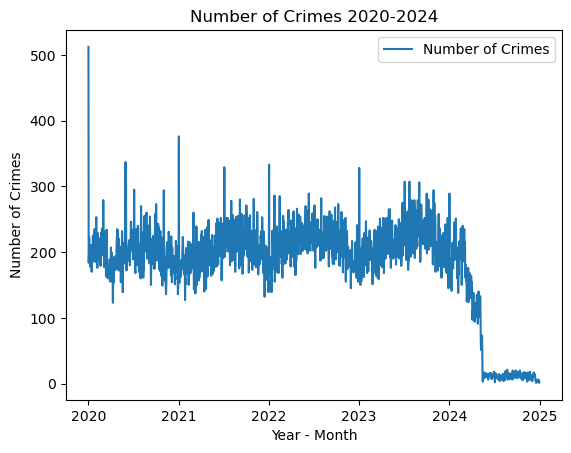

In [52]:
# Visualize the time series
plt.plot(crime_daily["Counts"], label='Number of Crimes')
plt.xlabel('Year - Month')
plt.ylabel('Number of Crimes')
plt.legend()
plt.title('Number of Crimes 2020-2024')
plt.show();

We noticed the number of occured crime dropped drastically after the middle of 2024. The reason could be there are still many hidden crimes that haven't been reported to the police in the recent years. To make the model work more efficiently, we decided to only use data from 2020 to mid-2024 and dropping all the rest.

In [53]:
# Get the index of the date 2024-03-01
end = crime_daily.index.get_loc("2024-03-01")
crimes = crime_daily.iloc[:end+1]
crimes.tail()

,Counts
DATE OCC,
2024-02-26,197
2024-02-27,186
2024-02-28,227
2024-02-29,212
2024-03-01,235


We will only use data from 2022-2024 for this project.

In [54]:
# Get the index of the date 2022-03-01
start = crimes.index.get_loc("2022-03-01")
crimes_2022_2024 = crimes.iloc[start+1:]
crimes_2022_2024.head()

,Counts
DATE OCC,
2022-03-02,207
2022-03-03,182
2022-03-04,203
2022-03-05,193
2022-03-06,231


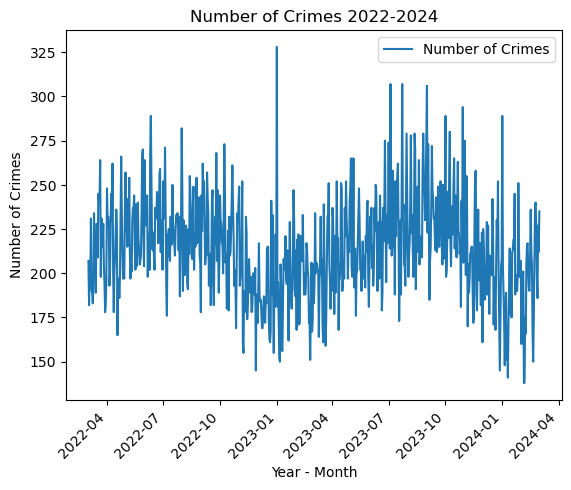

In [55]:
# Visualize the time series again
plt.plot(crimes_2022_2024["Counts"], label='Number of Crimes')
plt.xlabel('Year - Month')
plt.xticks(rotation=45, ha="right")
plt.ylabel('Number of Crimes')
plt.legend()
plt.title('Number of Crimes 2022-2024')
plt.show();

The data looks better now!

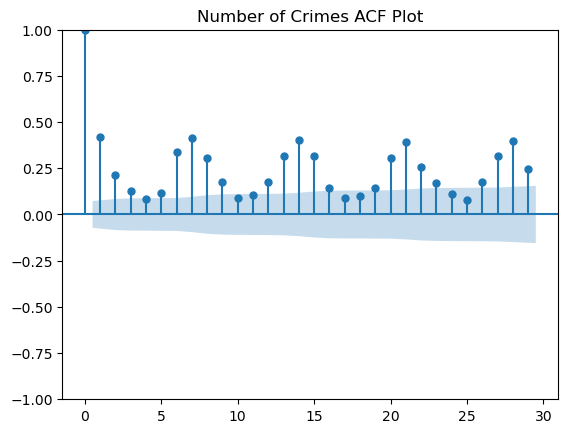

In [56]:
# Get the ACF Plot
series = crimes_2022_2024["Counts"]
plot_acf(series, title="Number of Crimes ACF Plot")
plt.show()

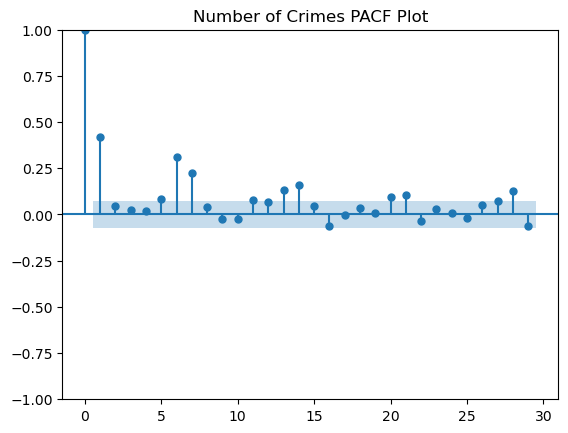

In [57]:
# Get the PACF plot
plot_pacf(series, title="Number of Crimes PACF Plot")
plt.show()

In [58]:
# Prepare the data, split into 80% training set and 20% test set
train_size = int(0.8 * len(crimes_2022_2024))
train_data = crimes_2022_2024[:train_size]
test_data = crimes_2022_2024[train_size:]

y_train = np.array(train_data["Counts"]).reshape(-1, 1)
y_test = np.array(test_data["Counts"]).reshape(-1, 1)

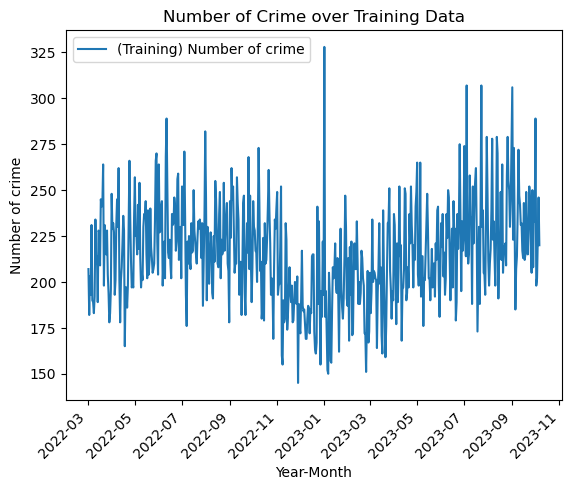

In [59]:
# Plotting
plt.plot(train_data["Counts"], label = "(Training) Number of crime")
plt.xlabel('Year-Month')
plt.ylabel('Number of crime')
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.title('Number of Crime over Training Data')
plt.show();

In [60]:
# Training values 
p = 14
train_ar = train_data.copy()

for lag in range(1, p + 1):
    train_ar[f"Lag_{lag}"] = train_ar["Counts"].shift(lag)

train_ar = train_ar.dropna()
lag_cols = [f"Lag_{lag}" for lag in range(1, p + 1)]
X_train = train_ar[lag_cols].values
y_train = train_ar["Counts"].values
beta_hat = np.linalg.lstsq(X_train, y_train, rcond=None)[0]
history = list(train_data["Counts"].values)


In [61]:
# Predictions 
y_pred = []
for t in range(len(test_data)):
    x_input = np.array(history[-p:][::-1])
    yhat = np.dot(beta_hat, x_input)
    y_pred.append(yhat)
    history.append(yhat)

In [62]:
# Put predictions into a data frame
pred_data = pd.DataFrame({
    "Counts": y_pred
}, index=test_data.index)

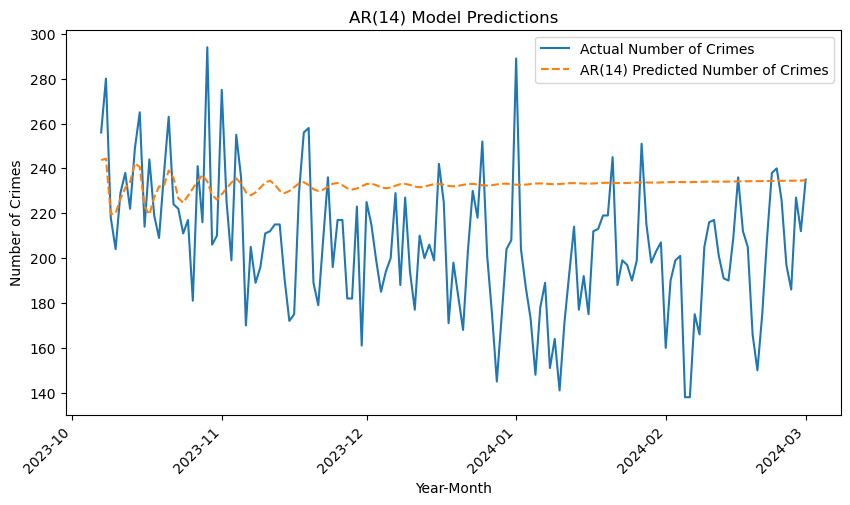

In [63]:
# Plot
plt.figure(figsize=(10, 5))
plt.plot(test_data["Counts"], label="Actual Number of Crimes")
plt.plot(pred_data["Counts"], label="AR(14) Predicted Number of Crimes", linestyle="--")
plt.xlabel("Year-Month")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Crimes")
plt.legend()
plt.title("AR(14) Model Predictions")
plt.show()